In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from collections import Counter
from nltk.util import ngrams
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import BertForSequenceClassification, BertTokenizer
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from nltk.corpus import stopwords
import string
stopwords = set(stopwords.words('english'))

c:\Users\jiyon\Desktop\Programming_projects\UNSW\musictransformationanalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('punkt')
nltk.download('stopwords')
# set sns plot 
sns.set_theme()
sns.set_theme(style="whitegrid")
sns.set_context("talk")
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth":1}

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jiyon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jiyon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.DataFrame(columns=["song_title", "song_lyrics"])

In [4]:
def merge_contractions(tokens):
    merged = []
    i = 0
    while i < len(tokens):
        # gonna = gon + na
        if i + 1 < len(tokens) and tokens[i] == "gon" and tokens[i+1] == "na":
            merged.append("gonna")
            i += 2
        # wanna = wan + na
        elif i + 1 < len(tokens) and tokens[i] == "wan" and tokens[i+1] == "na":
            merged.append("wanna")
            i += 2
        # gotta = got + ta
        elif i + 1 < len(tokens) and tokens[i] == "got" and tokens[i+1] == "ta":
            merged.append("gotta")
            i += 2
        # lemme = lem + me
        elif i + 1 < len(tokens) and tokens[i] == "lem" and tokens[i+1] == "me":
            merged.append("lemme")
            i += 2
        # gimme = gim + me
        elif i + 1 < len(tokens) and tokens[i] == "gim" and tokens[i+1] == "me":
            merged.append("gimme")
            i += 2
        # outta = out + ta
        elif i + 1 < len(tokens) and tokens[i] == "out" and tokens[i+1] == "ta":
            merged.append("outta")
            i += 2
        # kinda = kind + a
        elif i + 1 < len(tokens) and tokens[i] == "kind" and tokens[i+1] == "a":
            merged.append("kinda")
            i += 2
        # lotta = lot + ta
        elif i + 1 < len(tokens) and tokens[i] == "lot" and tokens[i+1] == "ta":
            merged.append("lotta")
            i += 2
        else:
            merged.append(tokens[i])
            i += 1
    return merged


In [5]:
def censor_words(tokens):  # renamed 'text' to 'tokens' to be clearer
    word_censor = {
        "nigga": "n*gga",
        "nigger": "n*gger",
        "anal": "@n@l",
        "booty": "b**ty",
        "pussy": "p*ssy",
        "sex": "s*x",
        "niggas": "n*ggas"
    }
    return [word_censor.get(word, word) for word in tokens]

def clean_lyrics(text, include_labels=False):
    # normalize apostrophes
    text = text.replace("’", "'")

    if include_labels:
        text = re.sub(r"(?<!\[)[\"'(),{}\]?](?!])", "", text)
    else:
        text = re.sub(r"\[.*?\]", "", text)
        text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    text = text.lower()
    tokens = word_tokenize(text)

    # merge contractions like gon+na → gonna
    tokens = merge_contractions(tokens)

    tokens = censor_words(tokens)
    tokens = [token for token in tokens if token not in stopwords]

    return tokens


In [6]:
def create_ngram_df(lyrics, artist):
    ngram_df = pd.DataFrame(columns=["ngram", "freq", "ngram_type"])
    bigram = Counter(list(ngrams(lyrics, 2)))
    trigram = Counter(list(ngrams(lyrics, 3)))
    for bi, freq in bigram.items():
        ngram_df = pd.concat([pd.DataFrame([[bi, freq, "bigram"]], columns=ngram_df.columns), ngram_df], ignore_index=True)
    for tri, freq in trigram.items():
        ngram_df = pd.concat([pd.DataFrame([[tri, freq, "trigram"]], columns=ngram_df.columns), ngram_df], ignore_index=True)
    ngram_df['artist'] =  artist
    return ngram_df

In [7]:
def get_top_ngrams(df):
    top_10_bigrams = df[df['ngram_type'] == "bigram"].sort_values("freq", ascending=False).head(10)
    top_10_trigrams = df[df['ngram_type'] == "trigram"].sort_values("freq", ascending=False).head(10)
    return top_10_bigrams, top_10_trigrams

In [8]:
def read_lyrics(artists=["Kanye West (AI)", "Cardi B (AI)", "Elton John (AI)", "Tom Macdonald (AI)"]):
    lyrics = {}
    for i, artist in enumerate(artists, start=1):
        with open(f"./song{i}/lyrics_new.txt", "r", encoding="utf-8") as f:
            contents = f.read()
        lyrics[artist] = contents
    return lyrics



def create_df():
    res = pd.DataFrame(columns=["ngram", "freq", "ngram_type", "artist"])
    artist_lyrics = read_lyrics()
    for artist, lyric in artist_lyrics.items():
        ngram_df = create_ngram_df(clean_lyrics(lyric), artist)
        res = pd.concat([res, ngram_df], ignore_index=True)
    return res


In [9]:
ngram_df = create_df() # concatenate the songs into one df

In [10]:
ngram_df

,ngram,freq,ngram_type,artist
0,"(higher, people, shining)",1,trigram,Kanye West (AI)
1,"(hands, yeah, rise)",1,trigram,Kanye West (AI)
2,"(worlds, hands, yeah)",1,trigram,Kanye West (AI)
3,"(like, worlds, hands)",1,trigram,Kanye West (AI)
4,"(feels, like, worlds)",1,trigram,Kanye West (AI)
...,...,...,...,...
1682,"(take, time)",1,bigram,Tom Macdonald (AI)
1683,"(didnt, take)",1,bigram,Tom Macdonald (AI)
1684,"(things, didnt)",1,bigram,Tom Macdonald (AI)
1685,"(guilty, things)",1,bigram,Tom Macdonald (AI)


In [11]:
ngram_df['rank'] = ngram_df.groupby(['ngram_type', 'artist'])['freq'].rank(method="first", ascending=False)
top_ngrams = ngram_df[ngram_df['rank'] <= 10].drop(columns="rank")

In [12]:
top_ngrams

,ngram,freq,ngram_type,artist
17,"(timeless, yeah, rise)",2,trigram,Kanye West (AI)
18,"(people, timeless, yeah)",2,trigram,Kanye West (AI)
19,"(higher, people, timeless)",2,trigram,Kanye West (AI)
20,"(rise, higher, people)",3,trigram,Kanye West (AI)
21,"(hey, yeah, rise)",3,trigram,Kanye West (AI)
...,...,...,...,...
1597,"(stand, use)",4,bigram,Tom Macdonald (AI)
1598,"(facts, stand)",4,bigram,Tom Macdonald (AI)
1599,"(learn, facts)",4,bigram,Tom Macdonald (AI)
1600,"(stand, learn)",4,bigram,Tom Macdonald (AI)


In [13]:
import matplotlib.patheffects as path_effects
import numpy as np

def make_artist_ngram_plot(top_ngrams):
    artists = ["Kanye West (AI)", "Cardi B (AI)", "Elton John (AI)", "Tom Macdonald (AI)"]
    
    # Enhanced color palette with more vibrant colors
    artist_colors = {
        "Kanye West (AI)": ['#3498db', '#e74c3c'],       # Bright blue & red
        "Cardi B (AI)":    ['#2ecc71', '#f39c12'],       # Emerald green & orange
        "Elton John (AI)": ['#9b59b6', '#e91e63'],       # Purple & pink
        "Tom Macdonald (AI)": ['#f1c40f', '#1abc9c'],    # Yellow & teal
    }
    
    # Define bar style with enhanced effects
    barstyle = {
        'edgecolor': 'black',
        'linewidth': 1,
        'alpha': 0.9,
    }
    
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelcolor': '#333333',
        'axes.titlepad': 20
    })
    
    fig, axes = plt.subplots(len(artists), 2, figsize=(14, 6 * len(artists)), 
                           constrained_layout=True, facecolor='#f8f9fa')
    
    for i, artist in enumerate(artists):
        bigram = top_ngrams[
            (top_ngrams['artist'] == artist) & 
            (top_ngrams['ngram_type'] == 'bigram')
        ]
        trigram = top_ngrams[
            (top_ngrams['artist'] == artist) & 
            (top_ngrams['ngram_type'] == 'trigram')
        ]
        
        # Plot bigram with enhanced styling
        bigram_sorted = bigram.sort_values('freq', ascending=True)
        ax_bigram = axes[i, 0]
        bigram_sorted.plot.barh(
            x='ngram',
            y='freq',
            ax=ax_bigram,
            color=artist_colors[artist][0],
            legend=False,
            **barstyle
        )
        

        ax_bigram.set_xlabel("Count", fontsize=20, fontweight='bold')
        ax_bigram.invert_xaxis()
        ax_bigram.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax_bigram.tick_params(axis='y', labelsize=20)
        ax_bigram.tick_params(axis='x', labelsize=18)
        ax_bigram.set_title(f"{artist}", fontsize=22, fontweight='bold',
                          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        ax_bigram.set_facecolor('#f8f9fa')
        
        # Plot trigram with enhanced styling
        trigram_sorted = trigram.sort_values('freq', ascending=True)
        ax_trigram = axes[i, 1]
        trigram_sorted.plot.barh(
            x='ngram',
            y='freq',
            ax=ax_trigram,
            color=artist_colors[artist][1],
            legend=False,
            **barstyle
        )
        
        
        ax_trigram.set_xlabel("Count", fontsize=20, fontweight='bold')
        ax_trigram.yaxis.set_tick_params(left=False, labelleft=False, right=True, labelright=True)
        ax_trigram.set_ylabel("")
        ax_trigram.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax_trigram.tick_params(axis='y', labelsize=20)
        ax_trigram.tick_params(axis='x', labelsize=18)
        ax_trigram.set_title(f"{artist}", fontsize=22, fontweight='bold',
                           path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        ax_trigram.set_facecolor('#f8f9fa')
    
    # Add overall title
    fig.suptitle('Most Frequent N-grams by Artist', 
                fontsize=24, fontweight='bold', y=1.02,
                path_effects=[path_effects.withStroke(linewidth=3, foreground='white')])
    
    plt.show()

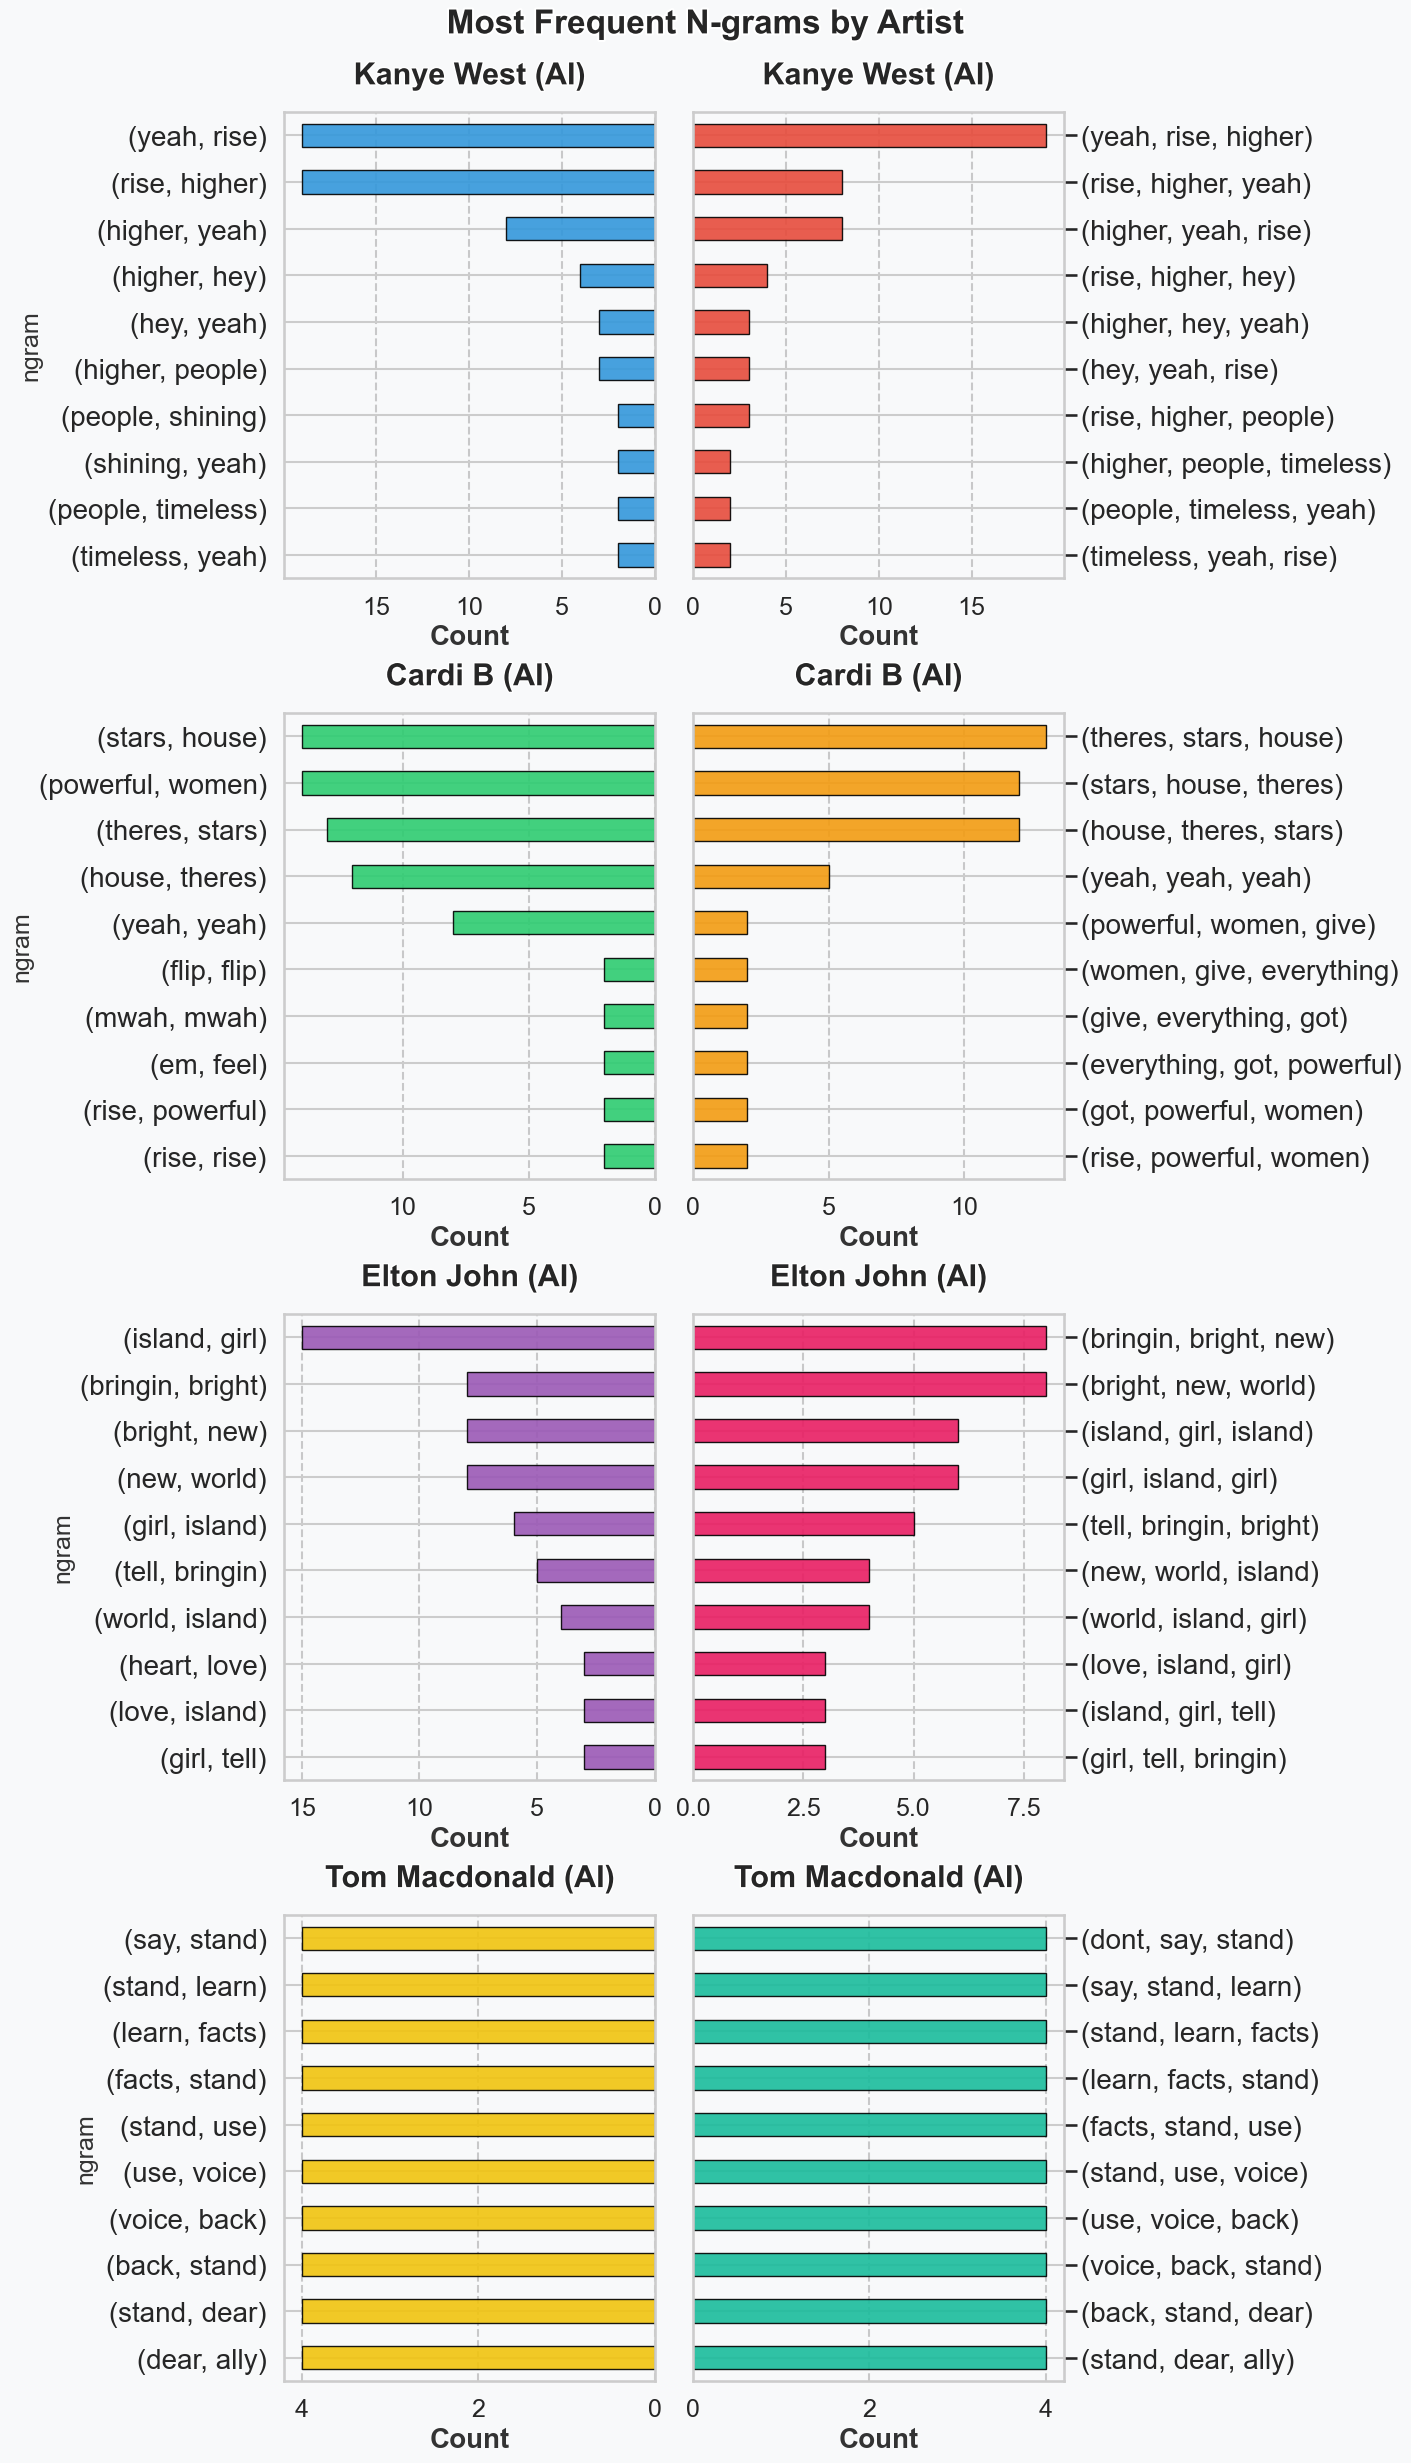

In [14]:
make_artist_ngram_plot(top_ngrams)

In [15]:
def preprocess_lines(lyrics):
    
    lines = lyrics.split("\n")
    lines = [x for x in lines if x != ""]
    return lines

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("Hate-speech-CNERG/bert-base-uncased-hatexplain")
model = AutoModelForSequenceClassification.from_pretrained("Hate-speech-CNERG/bert-base-uncased-hatexplain")

In [17]:
def predict_hate_speech(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    
    return predicted_class




In [18]:
from transformers import pipeline
sentiment = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [29]:
sentiment("thank you")

[{'label': 'POSITIVE', 'score': 0.9998352527618408}]

In [20]:
line_sentiment = pd.DataFrame(columns=["line", "sentiment", "section", "artist"])
artist_lyric = read_lyrics().items()

for artist, lyric in artist_lyric:
    current_section = None
    for line in preprocess_lines(lyric):
        if line.startswith("[") and line.endswith("]"):
            raw_section = line.strip("[]").strip()
            lower = raw_section.lower()

            # Use regex to match section types while preserving original labels
            if re.match(r"^verse(\b|:)", lower):
                current_section = "Verse"
            elif re.match(r"^(post-)?chorus(\b|:)", lower):
                current_section = "Chorus"
            elif re.match(r"^intro(\b|:)", lower):
                current_section = "Intro"  # Keep as Intro
            elif re.match(r"^outro(\b|:)", lower):
                current_section = "Outro"  # Keep as Outro
            elif re.match(r"^bridge(\b|:)", lower):
                current_section = "Bridge"  # Changed from Verse to Bridge
            else:
                current_section = None  # Unrecognized section, skip
            continue  # Skip the section label line itself

        if current_section is None:
            continue  # Skip lines not under a valid section

        s = 1 if sentiment(line)[0]['label'] == "NEGATIVE" else 0
        row = pd.DataFrame([[line, s, current_section, artist]], columns=line_sentiment.columns)
        line_sentiment = pd.concat([line_sentiment, row], ignore_index=True)

In [21]:
line_sentiment['line_number'] = line_sentiment.groupby("artist").cumcount()+1

In [22]:
line_sentiment.to_csv("./data/lines_new.csv")

In [23]:
df = line_sentiment.copy()
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df.sort_values(["artist", "line_number"])
df["cum_lines"] = df.groupby("artist").cumcount() + 1
df["cumulative_neg"] = df.groupby("artist")["sentiment"].cumsum()
df["cumulative_neg_prop"] = df["cumulative_neg"] / df["cum_lines"]

In [24]:
def get_sentiment_score(text):
    return sentiment(text)

def get_and_standardize_sentiment(text):
    result = get_sentiment_score(text)[0]
    label = result['label']
    score = result['score']
    
    if label == 'POSITIVE':
        standardized = 0.5 - (score - 0.5)
    else: 
        standardized = 0.5 + (score - 0.5)
    
    standardized = max(0, min(1, standardized))
    return standardized

df['sentiment_score'] = df['line'].apply(get_and_standardize_sentiment)


In [25]:
df

,line,sentiment,section,artist,line_number,cum_lines,cumulative_neg,cumulative_neg_prop,sentiment_score
32,Stars in this house,0,Intro,Cardi B (AI),1,1,0,0.000000,0.000144
33,There’s some stars in this house,0,Intro,Cardi B (AI),2,2,0,0.000000,0.000340
34,There’s some stars in this house,0,Intro,Cardi B (AI),3,3,0,0.000000,0.000340
35,There’s some stars in this house (Hol’ up),0,Intro,Cardi B (AI),4,4,0,0.000000,0.003698
36,"I said certified queen, seven days a week",0,Intro,Cardi B (AI),5,5,0,0.000000,0.000751
...,...,...,...,...,...,...,...,...,...
229,Try to see the world through another’s eyes,0,Chorus,Tom Macdonald (AI),82,82,24,0.292683,0.039224
230,"Stand up, don’t say that",1,Chorus,Tom Macdonald (AI),83,83,25,0.301205,0.620930
231,"Stand up, learn the facts",0,Chorus,Tom Macdonald (AI),84,84,25,0.297619,0.001239
232,"Stand up, use your voice back",0,Chorus,Tom Macdonald (AI),85,85,25,0.294118,0.055125


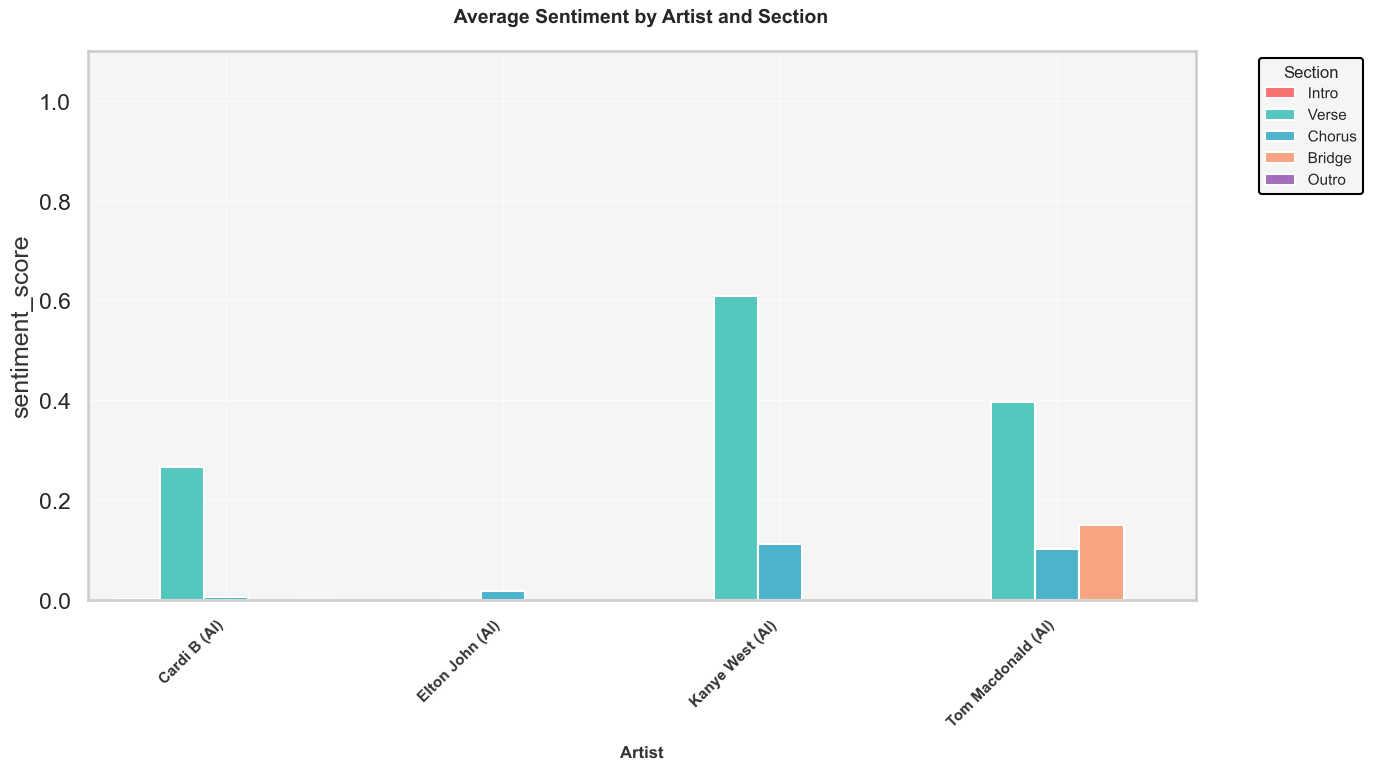

In [26]:
import matplotlib.patheffects as path_effects 
section_sentiment = df.groupby(['artist', 'section'])['sentiment_score'].mean().reset_index()

# Create a custom vibrant color palette for sections
section_colors = {
    'Intro': '#FF6B6B',    # Vibrant red
    'Verse': '#4ECDC4',    # Turquoise
    'Chorus': '#45B7D1',   # Bright blue 
    'Bridge': '#FFA07A',   # Light salmon
    'Outro': '#A569BD',    # Purple
    'Pre-Chorus': '#F4D03F',  # Yellow
    'Hook': '#58D68D'      # Green
}

plt.figure(figsize=(14, 8))

# Create the plot with custom colors
ax = sns.barplot(
    data=section_sentiment,
    x='artist',
    y='sentiment_score',
    hue='section',
    palette=section_colors,
    saturation=0.9,
    order=sorted(section_sentiment['artist'].unique()),
    hue_order=['Intro', 'Verse', 'Chorus', 'Bridge', 'Outro'],
    errorbar=None
)

# Customize the plot with vibrant style
plt.title('Average Sentiment by Artist and Section', pad=20, fontsize=14, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.xlabel('Artist', labelpad=12, fontsize=12, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.ylim(0, 1.1)



# Make the legend stand out
legend = plt.legend(
    title='Section',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    title_fontsize=12,
    fontsize=11,
    framealpha=1,
    edgecolor='black',
    facecolor='#f5f5f5'
)

# Apply text outline to legend
for text in legend.get_texts():
    text.set_path_effects([path_effects.withStroke(linewidth=1, foreground='white')])

# Style the plot background
ax.set_facecolor('#f5f5f5')
plt.grid(True, color='white', linestyle='-', linewidth=0.5)

# Rotate x-axis labels with style
plt.xticks(
    rotation=45, 
    ha='right',
    fontsize=11,
    fontweight='bold',
    color='#333333'
)

plt.tight_layout()
plt.show()

In [30]:
df.groupby("artist")["sentiment_score"].mean()

artist
Cardi B (AI)          0.163398
Elton John (AI)       0.013802
Kanye West (AI)       0.328793
Tom Macdonald (AI)    0.288435
Name: sentiment_score, dtype: float64

<Figure size 1200x600 with 0 Axes>

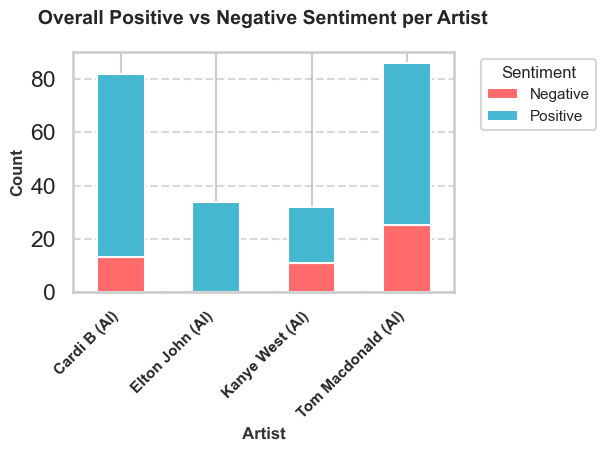

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Classify sentiment as Positive or Negative
df['sentiment_class'] = df['sentiment'].apply(lambda x: 'Positive' if x == 0 else 'Negative')

# -------------------------------
# 1. Overall positive vs negative per artist
# -------------------------------
artist_counts = df.groupby(['artist', 'sentiment_class']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
ax = artist_counts.plot(kind='bar', stacked=True, color={'Positive':'#45B7D1','Negative':'#FF6B6B'})

# Title + labels
plt.title('Overall Positive vs Negative Sentiment per Artist', fontsize=14, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.xlabel('Artist', fontsize=12, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=1.5, foreground='white')])
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.3)

# Move legend outside
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()
